# FitzHugh-Nagumo Bayesian Operator Inference (Baseline Method)

This notebook demonstrates the baseline Bayesian operator inference method for comparison.

**Configuration for Fair Comparison:**
- `RANDOM_SEED=42`: Ensures reproducible results (data noise, time sampling)
- `noiselevel=0.03`: Matches the SVI method
- `num_regression_points=num_samples*1`: Matches the SVI method

In [12]:
# Setup paths and imports
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), '..'))

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

import opinf

# Import from core and local config
from core import (
    summarize_experiment,
    generate_trajectory,
    fit_gaussian_processes,
    BayesianROM,
)
from core.scaler import DataScaler
import config

In [13]:
# Configuration parameters
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Experiment settings
training_span = (0, 3)
num_samples = 600
noiselevel = 0.01
num_regression_points = num_samples * 1
numPODmodes = 3
gp_regularizer = 1e0
ndraws = 200
USE_SCALED_DATA = True    # Standardize POD coefficients for GP fitting
USE_PRIOR = True         # Use deterministic OpInf solve as prior mean
PRIOR_REGULARIZER = 1e-4  # Regularization for prior computation (if USE_PRIOR)

# Update time domain in config
config.time_domain = np.linspace(0, 5, 801)

if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

In [14]:
# Report experimental scenario
summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
    figures_path="figures",
)

# Generate training data
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = generate_trajectory(config, config.time_domain, training_span, num_samples, noiselevel)

print(f"time_domain: {time_domain.shape}, true_states: {true_states.shape}")
print(f"time_domain_sampled: {time_domain_sampled.shape}, snapshots_sampled: {snapshots_sampled.shape}")


EXPERIMENTAL SCENARIO
Data: 600 uniformly sampled snapshots over 0.00 ≤ t < 3.00 with 1.00% noise
Dimension: retaining 3 POD modes
Training: using 600 regression points
GP regularization: eta = 1.00e+00
Posterior: 200 draws

generating training data...done in 0.24 s.
time_domain: (801,), true_states: (1024, 801)
time_domain_sampled: (600,), snapshots_sampled: (1024, 600)


In [15]:
# Dimensionality reduction (POD).
import time
start_time = time.time()

with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

# Optionally scale data for GP fitting
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=numPODmodes)
    data_scaler.fit(snapshots_compressed)
    gp_training_data = data_scaler.transform(snapshots_compressed)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    gp_training_data = snapshots_compressed
    print("Scaling disabled: using raw POD coefficients")

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 600)
(3, 801)
done in 0.09 s.
Scaling enabled: DataScaler(num_modes=3, fitted=True, mean_range=[-5.995e-01, 1.434e+01], std_range=[1.449e+00, 1.211e+01])


In [16]:
# Fit Gaussian process kernels to the compressed training data
time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)

gps = fit_gaussian_processes(
    time_domain_training=time_domain_training,
    time_domain_sampled=time_domain_sampled,
    snapshots_sampled=gp_training_data,
    gp_regularizer=gp_regularizer,
    constant_bounds=config.CONSTANT_VALUE_BOUNDS,
    length_scale_bounds=config.LENGTH_SCALE_BOUNDS,
    noise_level_bounds=config.NOISE_LEVEL_BOUNDS,
    n_restarts_optimizer=config.N_RESTARTS_OPTIMIZER,
)

# If data was scaled for GP fitting, unscale state/derivative estimates
# back to original space so that WLS learns the operator in original space.
if USE_SCALED_DATA and data_scaler is not None:
    for i, gp in enumerate(gps):
        std_i = data_scaler.stds_[i, 0]
        mean_i = data_scaler.means_[i, 0]
        gp.state_estimate = gp.state_estimate * std_i + mean_i
        gp.ddt_estimate = gp.ddt_estimate * std_i  # derivatives: no mean shift
    print("GP outputs unscaled to original space for WLS")

q0 = snapshots_compressed[:, 0]


fitting GP model for state 'r_01'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 3.9547e-01
	\ell = 4.6257e-02
	\chi = 1.1946e-06
done in 49.93 s.
computing weight matrix...done in 0.06 s.

fitting GP model for state 'r_02'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 4.4389e-01
	\ell = 4.0875e-02
	\chi = 9.0691e-06
done in 32.20 s.
computing weight matrix...done in 0.06 s.

fitting GP model for state 'r_03'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 4.4505e-01
	\ell = 4.1127e-02
	\chi = 3.1265e-06
done in 29.93 s.
computing weight matrix...done in 0.06 s.
GP outputs unscaled to original space for WLS


In [17]:
# Estimate posterior using GP-BayesOpInf
import step3_estimate as step3

# Create the posterior and fit it 
input_func = config.ReducedOrderModel.input_func
inputs = None if input_func is None else input_func(time_domain_training)

bayesian_model = step3.estimate_posterior(
    time_domain=np.array(time_domain),
    gps=gps,
    inputs=np.array(inputs),
    use_prior=USE_PRIOR,
    prior_regularizer=PRIOR_REGULARIZER,
)

constructing posterior hyperparameters...

GRIDSEARCH
(1/81) Testing regularizer 1.0000e-16...21.17% error
(2/81) Testing regularizer 1.7783e-16...29.07% error
(3/81) Testing regularizer 3.1623e-16...21.95% error
(4/81) Testing regularizer 5.6234e-16...27.17% error
(5/81) Testing regularizer 1.0000e-15...25.29% error
(6/81) Testing regularizer 1.7783e-15...23.17% error
(7/81) Testing regularizer 3.1623e-15...25.51% error
(8/81) Testing regularizer 5.6234e-15...27.34% error
(9/81) Testing regularizer 1.0000e-14...35.70% error
(10/81) Testing regularizer 1.7783e-14...23.33% error
(11/81) Testing regularizer 3.1623e-14...31.76% error
(12/81) Testing regularizer 5.6234e-14...31.22% error
(13/81) Testing regularizer 1.0000e-13...27.55% error
(14/81) Testing regularizer 1.7783e-13...26.54% error
(15/81) Testing regularizer 3.1623e-13...29.89% error
(16/81) Testing regularizer 5.6234e-13...20.51% error
(17/81) Testing regularizer 1.0000e-12...28.59% error
(18/81) Testing regularizer 1.7783e-1

In [18]:
# Draw samples from the posterior.

time_domain_eval_training = np.linspace(0, max(time_domain_sampled), num_regression_points)

with opinf.utils.TimedBlock("sampling posterior distribution"):
    draws_compressed_training = []
    draws_compressed = []
    qbar = snapshots_compressed.mean(axis=1).reshape((-1, 1))
    bound = 5 * np.max(np.abs(snapshots_compressed - qbar), axis=1)
    num_unstables = 0
    Os = []
    for _ in range(ndraws):
        draw = bayesian_model.predict(
            initial_conditions=q0,
            timepoints=time_domain,
            input_func=input_func,
        )
        training_draw = bayesian_model.predict(
            initial_conditions=q0,
            timepoints=time_domain_eval_training,
            input_func=input_func,
        )
        Os.append(bayesian_model.rvs())
        if draw.shape[1] != time_domain.size or training_draw.shape[1] != time_domain_training.size:
            num_unstables += 1
            continue
        if np.any(np.abs(draw - qbar).max(axis=1) > bound):
            num_unstables += 1
            continue
        draws_compressed_training.append(training_draw)
        draws_compressed.append(draw)
    if num_unstables:
        print(f"\n{num_unstables}/{ndraws} draws unstable")

    # Translate results back to original state space.
    draws = [basis.decompress(draw) for draw in draws_compressed]
    Os = np.array(Os)

algo_time = time.time() - start_time
print(f"\nAlgorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")

sampling posterior distribution...done in 8.43 s.

Algorithm runtime: 262.6s (4.4min)


<Figure size 640x480 with 0 Axes>

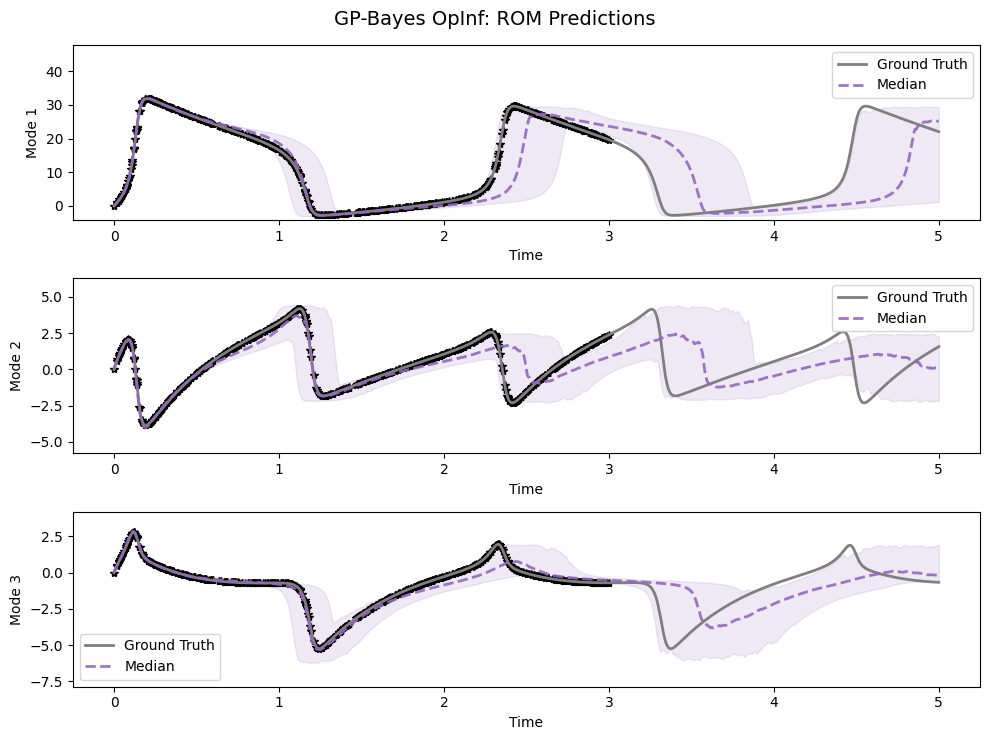


Stable draws: 200/200


In [19]:
# Visualize results using FitzPlotter (consistent with Full Bayesian notebook)
from fitz_plotter import FitzPlotter

plotter = FitzPlotter(
    numPODmodes=numPODmodes,
    time_domain_training=time_domain_sampled,
    time_domain_prediction=time_domain,
    time_domain_eval_training=time_domain_eval_training,
    time_domain_eval_prediction=time_domain,
    snapshots_training=snapshots_compressed,
    snapshots_prediction=full_states_compressed,
)

plotter.operator_plot_trajectories(
    draws_training=np.array(draws_compressed_training),
    draws_prediction=np.array(draws_compressed),
    time_domain_training=time_domain_eval_training,
    time_domain_prediction=time_domain,
    figsize=(10, 2.5 * numPODmodes),
    plot_single=True,
)
plt.suptitle('GP-Bayes OpInf: ROM Predictions', fontsize=14)
plt.show()

print(f"\nStable draws: {len(draws_compressed)}/{ndraws}")

Stable ROM solves: 200


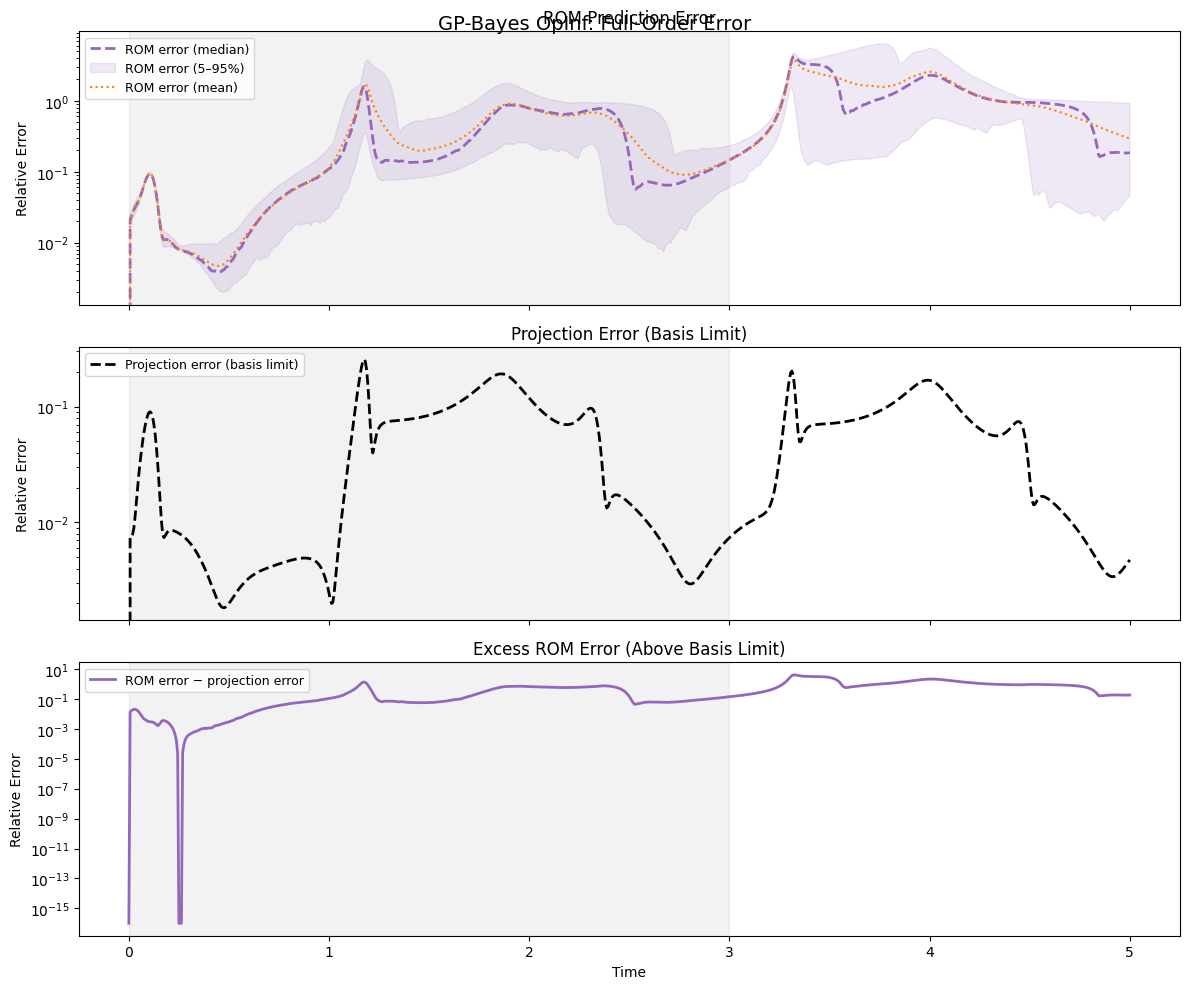

In [20]:
# Full-order prediction error (consistent with Full Bayesian notebook)
from core import plot_full_order_error

rom_solves_pred = np.array(draws_compressed)  # (num_stable, num_modes, num_time)
print(f"Stable ROM solves: {len(rom_solves_pred)}")

if len(rom_solves_pred) > 0:
    fig, axes = plot_full_order_error(
        rom_solves=rom_solves_pred,
        basis=basis,
        true_states=true_states,
        time_domain_full=time_domain,
        time_domain_eval=time_domain,
        training_span=training_span,
        error_type='relative',
        figsize=(12, 10),
    )
    plt.suptitle('GP-Bayes OpInf: Full-Order Error', fontsize=14)
    plt.show()